In [77]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2
using DataFrames

In [78]:
using Revise
using Newtrinos
using Newtrinos.osc

In [79]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 25.0, r = 1.0), (m₀ = Uniform{Float64}(a=0.001, b=2.0), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=100.0), r = Uniform{Float64}(a=0.0, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#50"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(OscillationCon

In [80]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [81]:
experiments = (

  dayabay= Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [82]:
p = Newtrinos.get_params(experiments)

(N = 25.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [83]:
using Setfield

In [84]:
# modify the value of m0 with a random value taken from a Distribution

sigma= 2*p.m₀/10
new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3))) 
new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
p_new_un = @set p.m₀ = new_m₀_un
p_new_norm = @set p.m₀ = new_m₀_norm


(N = 25.0, m₀ = 0.011784824266764339, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [85]:
assets= experiments.dayabay.assets

(E_arrs = [[1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43], [1.78, 2.21, 2.46, 2.7, 2.95, 3.2, 3.45, 3.7, 3.95, 4.2  …  5.95, 6.2, 6.45, 6.7, 6.95, 7.2, 7.45, 7.7, 7.95, 10.43]], L_arrs = [[1919.63, 1917.52, 1925.26, 1894.34, 1891.98, 1899.86, 1533.18, 1534.92, 1538.93, 1533.63, 1535.03, 1539.47, 1551.38, 1554.77, 1556.34, 1524.94, 1528.05, 1530.08], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18], [1919.63, 1917.52, 1925.26, 1923.15, 1894.34, 1891.98, 1899.86, 1897.51, 1533.18, 1534.92  …  1539.47, 1540.87, 1551.38, 1554.77, 1556.34, 1559.72, 1524.94, 1528.05, 1530.08, 1533.18]], Npred_EH3_nooscs = [[966.99789101819, 1311.4889551891888, 1854.178347329635, 2317.3210980

In [86]:
expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))


26-element Vector{Float64}:
 58683.157058321805
 61445.53315596223
 56519.75461637101
 69499.89946071543
 77747.89100078688
 86501.67799567778
 87241.9223879332
 82603.50193058638
 78442.43171543481
 73176.89155654877
 66087.65009031561
 59794.070464079065
 53827.77648714707
 48983.98530441899
 44640.0455919352
 39801.41622254801
 33540.9559577622
 34524.830351672135
 25290.57352152402
 19847.196284768106
 14652.320866625862
  9873.00899303492
  6412.734078833364
  6734.7662812843055
  3692.451421456397
 17214.150144629955

In [87]:
expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))


26-element Vector{Float64}:
 58699.80968293805
 61478.205566770106
 56503.05225210458
 69631.02206317523
 77681.69377431856
 86579.06364931581
 87261.92190183657
 82575.83966034715
 78414.01780770646
 73175.24125937468
 66077.90439331325
 59826.00171515255
 53864.068918888355
 48989.982442463726
 44658.75214498827
 39882.05228469272
 33551.67534388238
 34514.95056863967
 25282.679109722394
 19829.33454804903
 14657.220316958317
  9876.757811322303
  6407.631142370221
  6732.682505272897
  3694.30866301458
 17228.54290481456

In [88]:
using CairoMakie

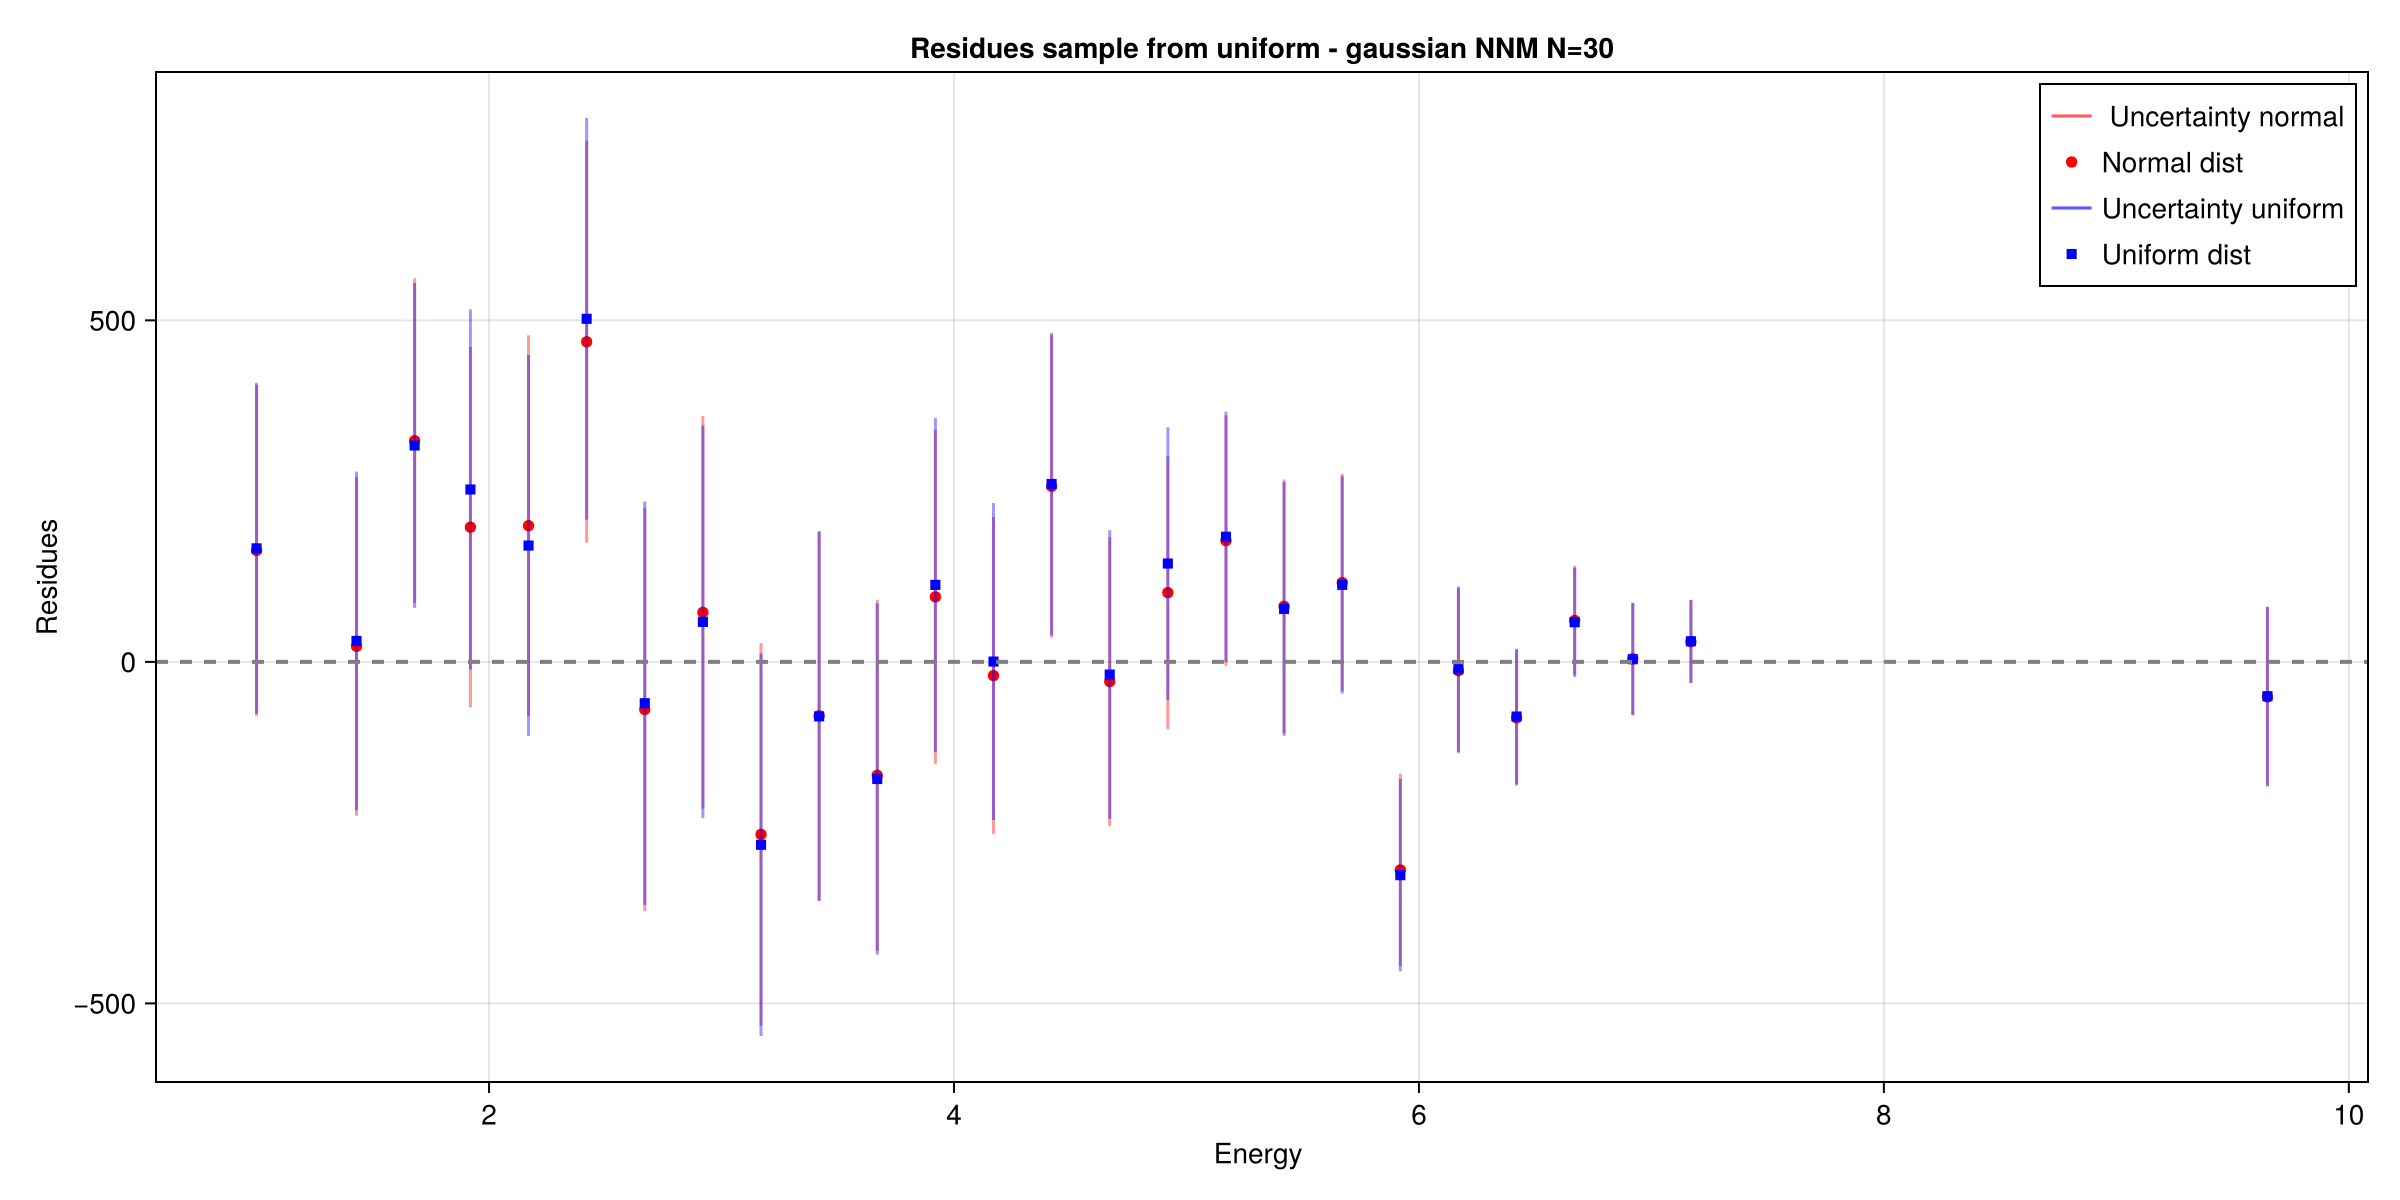

CairoMakie.Screen{IMAGE}


In [89]:

# Create the figure
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "Energy ",
    ylabel = "Residues", 
    title = "Residues sample from uniform - gaussian NNM N=30")


errorbars!(ax, assets.energy,  assets.observed-expected_norm,  sqrt.(expected_norm_var), 
      color = (:red, 0.4), label = " Uncertainty normal")

scatter!(ax, assets.energy,  assets.observed-expected_norm, 
        color = :red, markersize = 8, label = "Normal dist")

errorbars!(ax, assets.energy,  assets.observed-expected_un,sqrt.(expected_un_var), 
      color = (:blue, 0.4), label = "Uncertainty uniform")
      
scatter!(ax, assets.energy, assets.observed-expected_un, 
        color = :blue, marker = :rect, markersize = 8,label = "Uniform dist")

        
# Add a horizontal line at zero for reference
hlines!(ax, [0], color = :gray, linestyle = :dash, linewidth = 2)

    
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/dayabay/nm_dayabay_NNM_N30_residues.png", fig)

In [90]:
#img = experiments.dayabay.plot(p_new_norm)
#display("image/png", img)

In [91]:

using ProgressMeter
using MeasureBase

In [99]:
function random_sampling(physics, experiments, p, N)

   chi_squared_un_list = Float64[]
   chi_squared_norm_list = Float64[]

   @showprogress for i in 1:100
      #println("Random sampling iteration: $i")
      sigma=2*p.m₀/1000
      new_m₀_un = rand(Uniform(p.m₀, p.m₀*sqrt(3)))
      new_m₀_norm= rand(truncated(Normal(p.m₀,sigma), p.m₀, p.m₀*sqrt(3)))
      p_new_un = @set p.m₀ = new_m₀_un
      p_new_norm = @set p.m₀ =new_m₀_norm
      #p_new_un = @set p.N = N
      #p_new_norm = @set p.N = N


      assets= experiments.dayabay.assets
      observed = assets.observed

      expected_un = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_un_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un))
      expected_norm = mean(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))
      expected_norm_var = var(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm))

    
      likelihood_norm=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_norm), observed)
      likelihood_un=logdensityof(Newtrinos.dayabay.get_forward_model(physics, assets)(p_new_un), observed)

      push!(chi_squared_un_list, likelihood_un)
      push!(chi_squared_norm_list, likelihood_norm)

   end
   return chi_squared_un_list, chi_squared_norm_list
end

random_sampling (generic function with 1 method)

In [100]:
trial=random_sampling(physics, experiments, p, 25)

Progress: 100%|█████████████████████████████████████████| Time: 0:06:28


([-168.13281972410957, -169.11626778846409, -168.50231470140127, -168.94650636484596, -169.05333681575257, -168.84784086877713, -168.79156315058427, -168.5836281909974, -168.50262442532318, -168.48935434023778  …  -168.73507988148438, -168.86371758388646, -168.628105129092, -168.60784923493756, -168.62787370152262, -169.0597286065816, -168.40110183629238, -168.72122316741465, -168.7580135057886, -168.6414443780903], [-168.34733309235241, -168.52628040330515, -168.34333789264727, -168.56444709850857, -168.42619455809194, -168.32819245647116, -168.81071967921608, -168.80962206604352, -168.42315994636127, -168.36925456862684  …  -168.87426412072816, -168.34532020493734, -168.3989200615423, -168.8181108899488, -168.81326243120682, -168.3360839993102, -168.5323996454173, -168.5242086755053, -168.4765779941061, -168.4996458652558])

In [101]:
trial=.-trial # to have the negative log likelihood

([168.13281972410957, 169.11626778846409, 168.50231470140127, 168.94650636484596, 169.05333681575257, 168.84784086877713, 168.79156315058427, 168.5836281909974, 168.50262442532318, 168.48935434023778  …  168.73507988148438, 168.86371758388646, 168.628105129092, 168.60784923493756, 168.62787370152262, 169.0597286065816, 168.40110183629238, 168.72122316741465, 168.7580135057886, 168.6414443780903], [168.34733309235241, 168.52628040330515, 168.34333789264727, 168.56444709850857, 168.42619455809194, 168.32819245647116, 168.81071967921608, 168.80962206604352, 168.42315994636127, 168.36925456862684  …  168.87426412072816, 168.34532020493734, 168.3989200615423, 168.8181108899488, 168.81326243120682, 168.3360839993102, 168.5323996454173, 168.5242086755053, 168.4765779941061, 168.4996458652558])

In [102]:
mean_un=mean(trial[1])
mean_norm=mean(trial[2])

168.5041993414529

In [103]:
# standard model for comparison
osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc= Newtrinos.osc.configure(osc_cfg_SM)

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc, atm_flux, earth_layers);

experiments_SM = (

  dayabay= Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

likelihood_SM=-logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

[ Info: Loading dayabay data


168.90003273508322

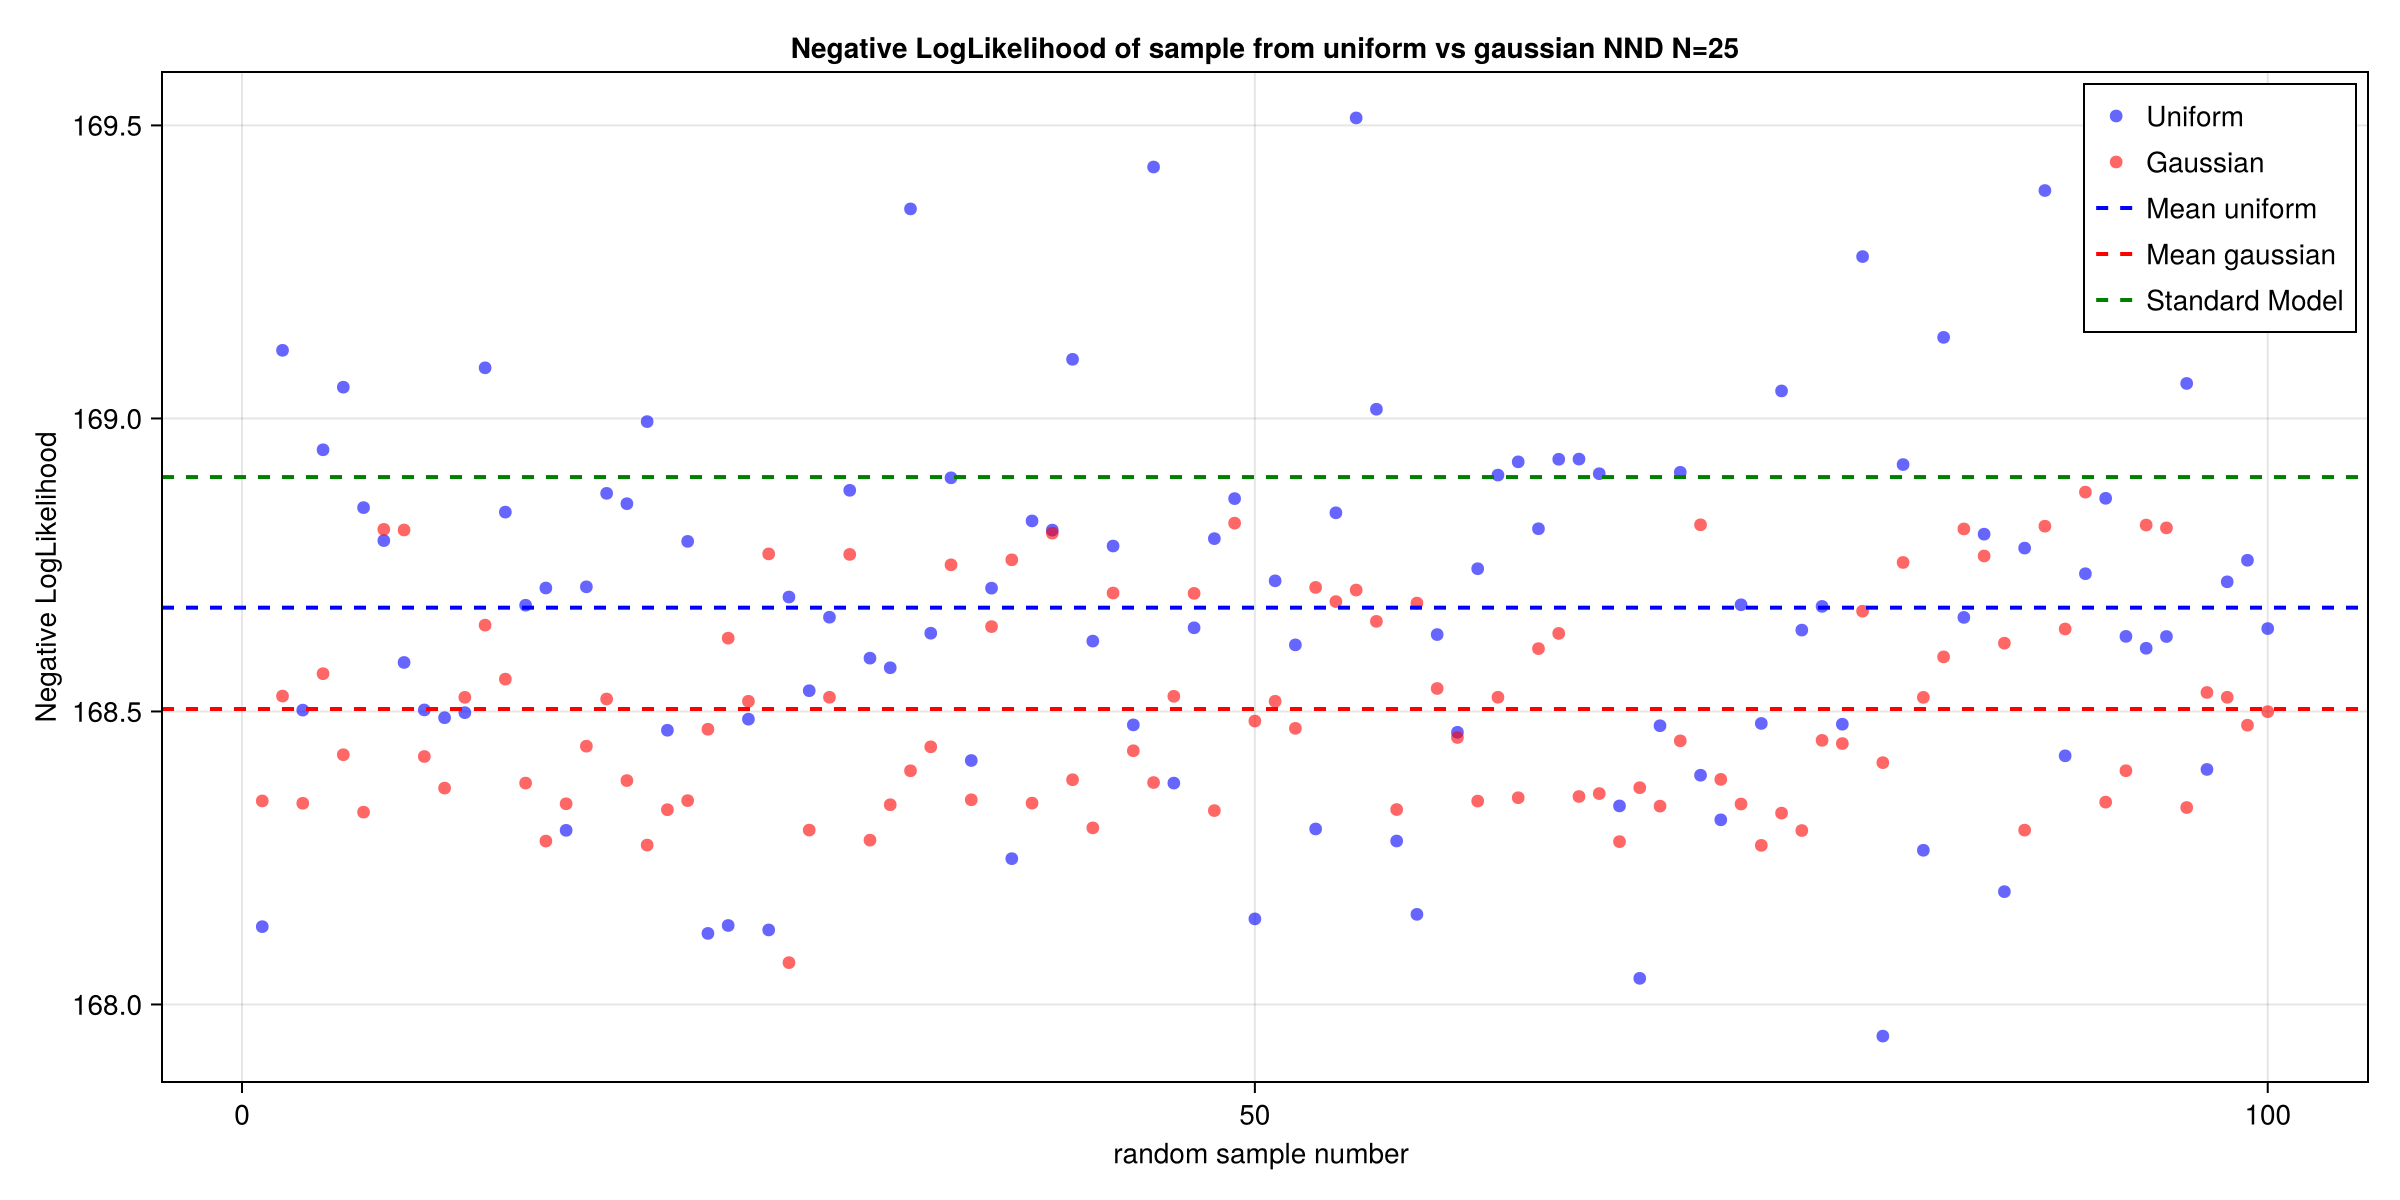

CairoMakie.Screen{IMAGE}


In [104]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = "random sample number ",
    ylabel = "Negative LogLikelihood", 
    title = "Negative LogLikelihood of sample from uniform vs gaussian NND N=25")
scatter!(ax, 1:100, trial[1], color = (:blue, 0.6), label = "Uniform")
scatter!(ax, 1:100, trial[2], color = (:red, 0.6), label = "Gaussian")


hlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
hlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
hlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

# Show the plot
display(fig)

#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_samples_NNM_N20_m0=0.1.png", fig)

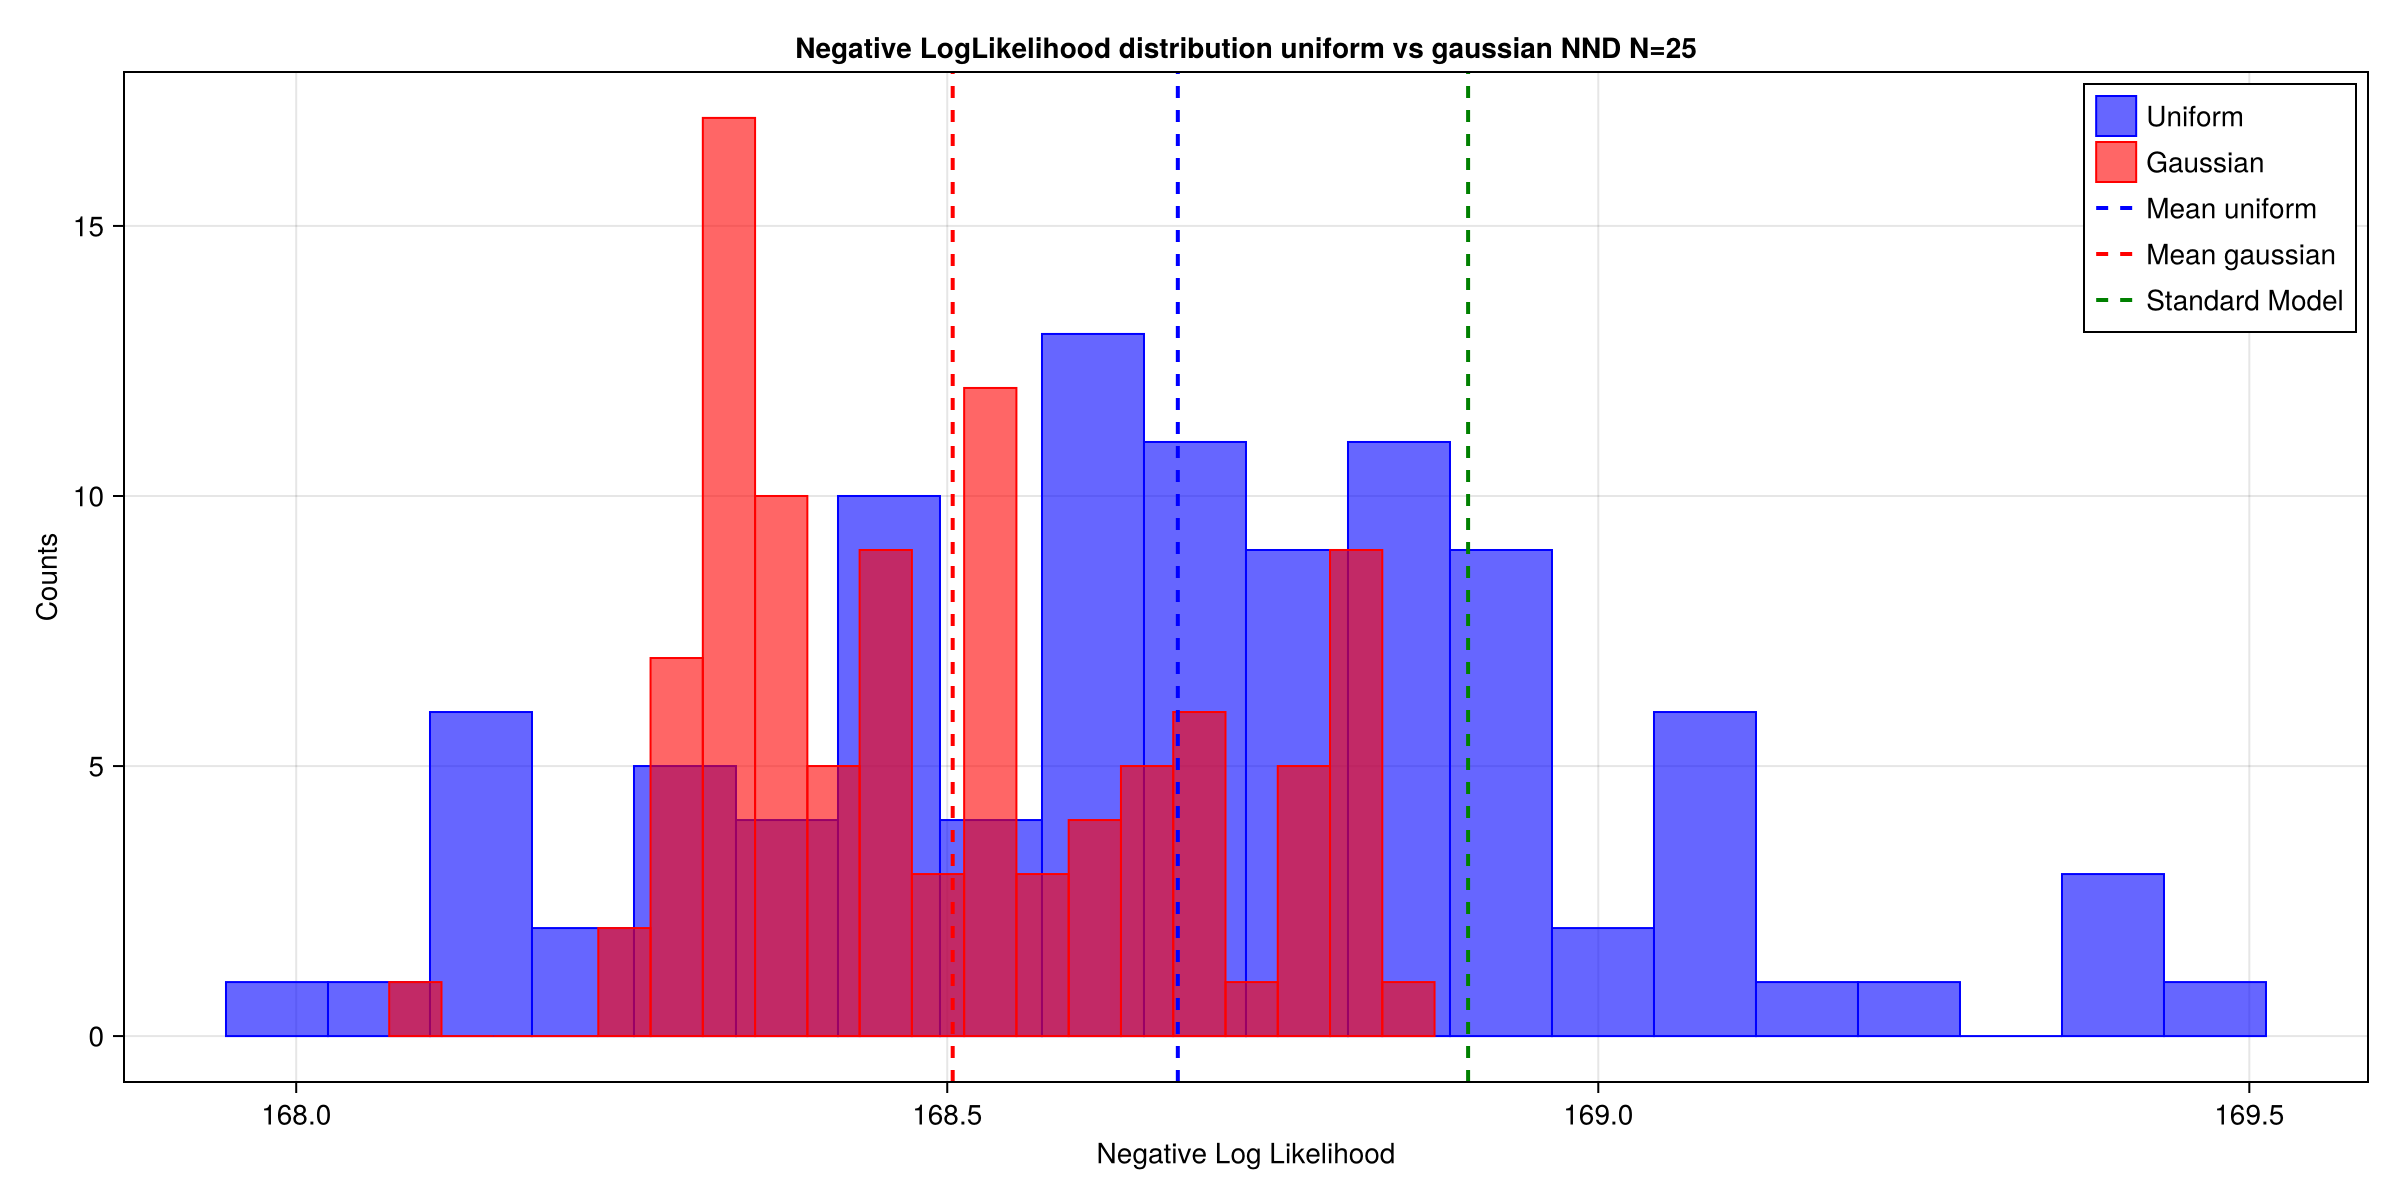

CairoMakie.Screen{IMAGE}


In [ ]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " Negative Log Likelihood ",
    ylabel = "Counts", 
    title = "Negative LogLikelihood distribution uniform vs gaussian NND N=25")

hist!(ax, trial[1], bins = 20, color = (:blue, 0.6), strokewidth = 1, strokecolor = :blue, label = "Uniform")
hist!(ax, trial[2], bins = 20, color = (:red, 0.6), strokewidth = 1, strokecolor = :red, label = "Gaussian")



vlines!(ax, [mean_un], color = :blue, linestyle = :dash, linewidth = 2, label = "Mean uniform")
vlines!(ax, [mean_norm], color = :red, linestyle = :dash, linewidth = 2, label = "Mean gaussian")
vlines!(ax, likelihood_SM, color = :green, linestyle = :dash, linewidth = 2, label = "Standard Model")

# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)

save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_N25_m0=0.01.png", fig)

In [112]:
function lik_ratio(N)

    ratios_un = Float64[]
    ratios_norm = Float64[]

    pvalue_un = Float64[]
    pvalue_norm = Float64[]

    likelihood_SM=-Newtrinos.logdensityof(Newtrinos.dayabay.get_forward_model(physics_SM, assets)(p_SM), assets.observed)

   
    @showprogress for i in 20:N
       trial=random_sampling(physics, experiments, p, i)
       mean_un= mean(trial[1])
       mean_norm= mean(trial[2])
       ratio_a= (likelihood_SM-mean_un) # test SM (H0) vs uniform (H1)
       ratios_b= (mean_un-mean_norm) # test uniform (H0) vs gaussian (H1)

       push!(ratios_un, ratio_a)
       push!(ratios_norm, ratios_b)

       df_SM = 2
       df_r=1   # Difference in number of parameters

       p_value_a = 1 - cdf(Chisq(df_SM), ratio_a)
       p_value_b = 1 - cdf(Chisq(df_r), ratios_b)

        push!(pvalue_un, p_value_a)
        push!(pvalue_norm, p_value_b)

    end

     
    
    return ratios_un, ratios_norm, pvalue_un, pvalue_norm
end

lik_ratio (generic function with 1 method)

In [113]:
likelihood_ratios= lik_ratio(25)

Progress: 100%|█████████████████████████████████████████| Time: 0:07:14
Progress: 100%|█████████████████████████████████████████| Time: 0:07:47
Progress: 100%|█████████████████████████████████████████| Time: 0:06:47
Progress: 100%|█████████████████████████████████████████| Time: 0:06:39
Progress: 100%|█████████████████████████████████████████| Time: 0:06:54
Progress: 100%|█████████████████████████████████████████| Time: 0:06:36
Progress: 100%|█████████████████████████████████████████| Time: 0:42:02


([337.5741659631482, 337.57404705730164, 337.55472293667054, 337.5402875049664, 337.62987853197285, 337.5364406114901], [-0.1821642382169273, -0.173845811975184, -0.16611140233410993, -0.18891517342518682, -0.20644954494389367, -0.135938516885858], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

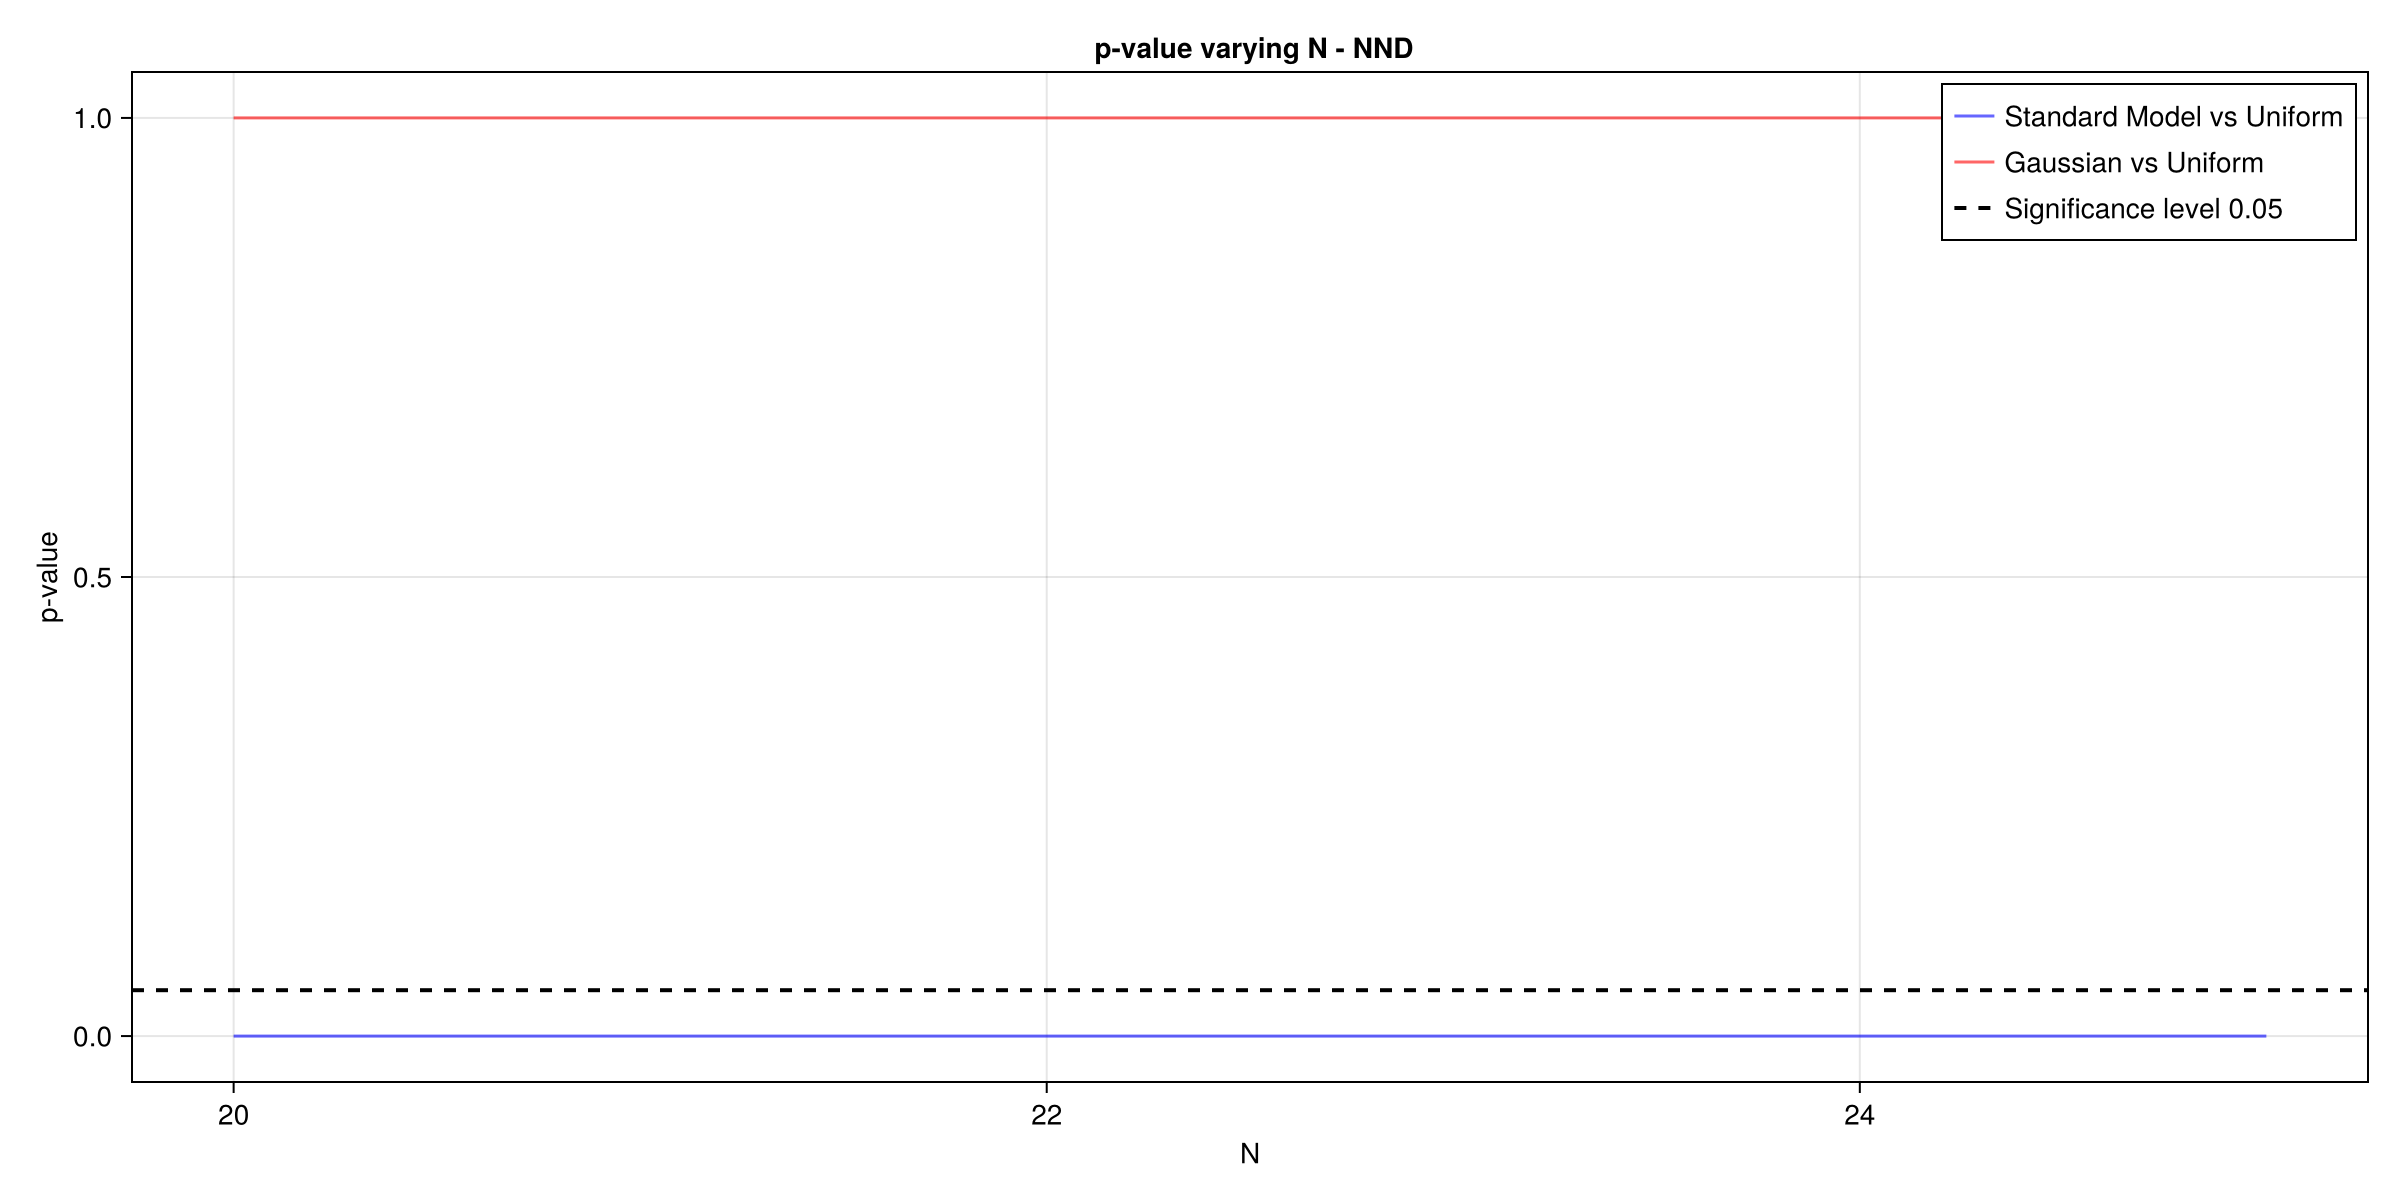

CairoMakie.Screen{IMAGE}


In [114]:
fig = Figure(size = (1200, 600))
ax = Axis(fig[1, 1], 
    xlabel = " N ",
    ylabel = "p-value", 
    title = " p-value varying N - NND")

x=20:25
lines!(x, likelihood_ratios[:][3], color = (:blue, 0.6),  label = "Standard Model vs Uniform")
lines!(x, likelihood_ratios[:][4], color = (:red, 0.6),  label = "Gaussian vs Uniform")

hlines!(0.05, color = :black, linestyle = :dash, linewidth = 2, label = "Significance level 0.05")
# Add legend
axislegend(ax, position = :rt)

# Add grid
ax.xgridvisible = true
ax.ygridvisible = true
ax.xgridcolor = (:black, 0.1)
ax.ygridcolor = (:black, 0.1)

display(fig)


#save("/home/sofialon/Newtrinos.jl/aug_plots/Newmethod/dayabay_nll_NNM_r=1_pvalue.png", fig)